In [1]:
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape, box
import os
from glob import glob
import pandas as pd
import numpy as np
import pandapower as pp

load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\zlib1.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\abseil_dll.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\utf8_validity.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\re2.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\libprotobuf.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\highs.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\ortools.dll...


In [6]:
# === Read power network data ===
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
loads_gdf = gpd.read_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_gdf_add_bus.gpkg')

In [7]:
lines_gdf = lines_gdf.dropna(subset=['fromNode', 'toNode'])
len(lines_gdf)

7444

In [8]:
"""
    The same physical substation is encoded as multiple logical nodes (e.g., 3559a, 3559b) representing different voltage levels,
    causing them to be treated as separate nodes during graph construction and leading to a false fragmentation of the network.
"""
# 定义函数去除节点 ID 最后一个字母（如果存在）
def remove_suffix_letter(val):
    if isinstance(val, str) and val[-1].isalpha():
        return val[:-1]
    return val

# Apply to nodes
nodes_gdf['NodeID_o'] = nodes_gdf['NodeID'].apply(remove_suffix_letter)

# 应用于 fromNode 和 toNode，创建新列
lines_gdf['fromNode_o'] = lines_gdf['fromNode'].apply(remove_suffix_letter)
lines_gdf['toNode_o'] = lines_gdf['toNode'].apply(remove_suffix_letter)

nodes_gdf.head()

,NodeID,voltage,lon,lat,lines_count,cables_count,capacity,OriginalID,geometry,NodeID_o
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,8,48,14400,153608703.0,POINT (610714.853 2315180.7),NODEVN3270
1,NODEVN0002,110.0,672622.408581,1.278800e+06,1,3,300,2.0,POINT (672622.409 1278800.027),NODEVN0002
2,NODEVN0003a,220.0,682154.017051,2.315888e+06,12,120,36000,4.0,POINT (682154.017 2315887.79),NODEVN0003
3,NODEVN3273a,110.0,684889.726446,2.304274e+06,7,39,13500,241065371.0,POINT (684889.726 2304273.827),NODEVN3273
4,NODEVN3273b,220.0,684710.914392,2.304283e+06,7,39,13500,241065371.0,POINT (684710.914 2304282.784),NODEVN3273


# Random node removal

In [20]:
import networkx as nx
import numpy as np
import pandas as pd

# 构建 NetworkX 无向图
# G = nx.Graph()
G = nx.MultiGraph()

# 添加节点
for node_id in nodes_gdf['NodeID_o']:
    G.add_node(node_id)

# 添加边
for _, row in lines_gdf.iterrows():
    G.add_edge(row['fromNode_o'], row['toNode_o'])

# 设置移除比例和重复次数
remove_fractions = np.linspace(0, 1, 21)  # 从0到100%，间隔5%
num_iterations = 10

results = []

# 渗流模拟
for frac in remove_fractions:
    for _ in range(num_iterations):
        G_temp = G.copy()
        num_remove = int(frac * G_temp.number_of_nodes())
        remove_nodes = np.random.choice(list(G_temp.nodes), size=num_remove, replace=False)
        G_temp.remove_nodes_from(remove_nodes)

        # 找最大连通子图占比
        if len(G_temp) > 0:
            largest_cc = max(nx.connected_components(G_temp), key=len)
            giant_component_ratio = len(largest_cc) / G.number_of_nodes()
        else:
            giant_component_ratio = 0

        results.append({
            "removal_fraction": frac,
            "giant_component_ratio": giant_component_ratio
        })

# 整理结果
percolation_df = pd.DataFrame(results)

In [19]:
# 使用MultiGraph()支持重复边（即fromNode和toNode一样的边）
# 若使用Graph()，总边数从原始的7444降为4062
# 构建图后查看：
print("Number of nodes:", G.number_of_nodes())
print("Number of lines:", G.number_of_edges())

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
print("Number of components:", len(components))
print("Size of the maximum component:", max(component_sizes))

Number of nodes: 4111
Number of lines: 4011
Number of components: 260
Size of the maximum component: 3300


In [17]:
# 使用MultiGraph()支持重复边（即fromNode和toNode一样的边）
# 若使用Graph()，总边数从原始的7444降为4062
# 构建图后查看：
print("Number of nodes:", G.number_of_nodes())
print("Number of lines:", G.number_of_edges())

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
print("Number of components:", len(components))
print("Size of the maximum component:", max(component_sizes))

Number of nodes: 4331
Number of lines: 4062
Number of components: 357
Size of the maximum component: 1774


In [21]:
# 使用MultiGraph()支持重复边（即fromNode和toNode一样的边）
# 若使用Graph()，总边数从原始的7444降为4062
# 构建图后查看：
print("Number of nodes:", G.number_of_nodes())
print("Number of lines:", G.number_of_edges())

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
print("Number of components:", len(components))
print("Size of the maximum component:", max(component_sizes))

Number of nodes: 4111
Number of lines: 7444
Number of components: 260
Size of the maximum component: 3300


In [28]:
set(nodes_gdf['NodeID']) - set(lines_gdf['fromNode']) - set(lines_gdf['toNode'])

{'NODEVN4111'}

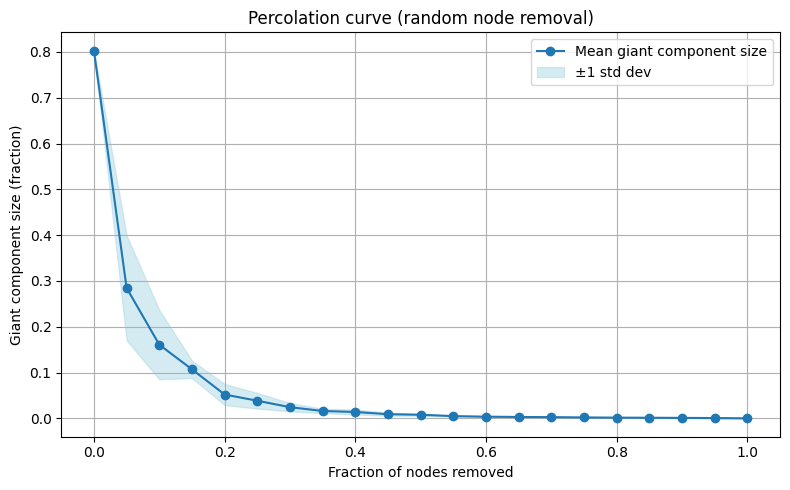

In [61]:
# 查看所有移除比例的平均 giant component 比例
percolation_summary = percolation_df.groupby("removal_fraction")["giant_component_ratio"].agg(['mean', 'std'])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(percolation_summary.index, percolation_summary['mean'], marker='o', label='Mean giant component size')
plt.fill_between(
    percolation_summary.index,
    percolation_summary['mean'] - percolation_summary['std'],
    percolation_summary['mean'] + percolation_summary['std'],
    color='lightblue', alpha=0.5, label='±1 std dev'
)
plt.xlabel('Fraction of nodes removed')
plt.ylabel('Giant component size (fraction)')
plt.title('Percolation curve (random node removal)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/percolation_curve_random_node_removal_0-1.png")
plt.show()

In [63]:
# 创建 group_id 到包含节点 ID 列表的映射
group_records = []
for group_id, component in enumerate(nx.connected_components(G)):
    node_ids = sorted(component)
    group_records.append({
        'group_id': group_id,
        'num_nodes': len(node_ids),
        'node_ids': node_ids
    })

# 构建 DataFrame
group_df = pd.DataFrame(group_records)
group_df

,group_id,num_nodes,node_ids
0,0,3300,"[NODEVN0001, NODEVN0003, NODEVN0004, NODEVN000..."
1,1,4,"[NODEVN0002, NODEVN3649, NODEVN3650, NODEVN3651]"
2,2,3,"[NODEVN0884, NODEVN3300, NODEVN3301]"
3,3,4,"[NODEVN0082, NODEVN0083, NODEVN2728, NODEVN3616]"
4,4,3,"[NODEVN0110, NODEVN0111, NODEVN3293]"
5,5,5,"[NODEVN0115, NODEVN0116, NODEVN0117, NODEVN330..."
6,6,4,"[NODEVN0120, NODEVN0121, NODEVN0122, NODEVN3657]"
7,7,2,"[NODEVN0232, NODEVN3864]"
8,8,2,"[NODEVN0251, NODEVN3576]"
9,9,9,"[NODEVN0296, NODEVN0297, NODEVN2278, NODEVN227..."


In [ ]:
group_df

C:\Users\mye500\AppData\Local\Temp\ipykernel_18796\2639949896.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab20', n_groups)


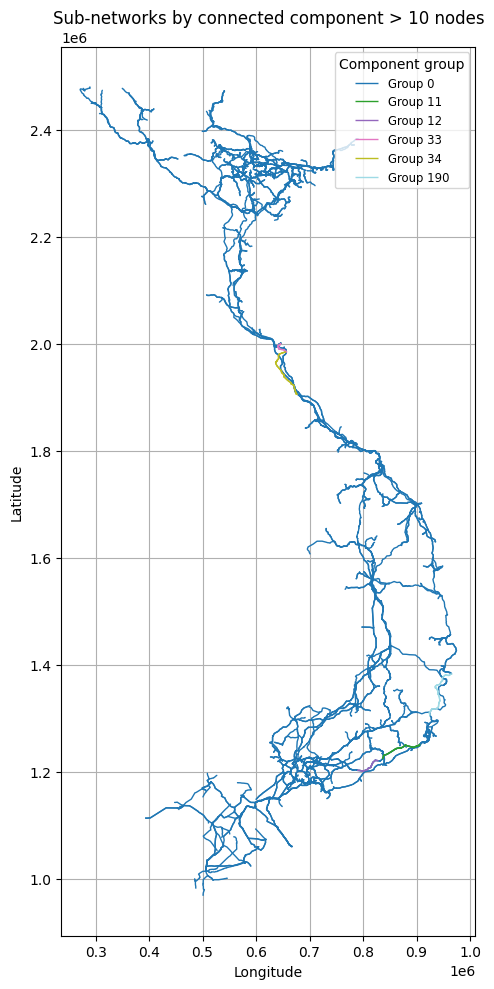

In [69]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 计算连通子图
connected_components = list(nx.connected_components(G))

# 为每个 node 映射 group_id，并计算子图大小
node_to_group = {}
component_sizes = {}
for group_id, component in enumerate(connected_components):
    size = len(component)
    component_sizes[group_id] = size
    for node in component:
        node_to_group[node] = group_id

# 加入 group_id 到 nodes 和 lines
nodes_gdf['group'] = nodes_gdf['NodeID_o'].map(node_to_group)
lines_gdf['group'] = lines_gdf['fromNode_o'].map(node_to_group)

# 只保留 group size > 100 的 group
large_groups = {gid for gid, size in component_sizes.items() if size > 10}
lines_large = lines_gdf[lines_gdf['group'].isin(large_groups)]

# 分配颜色
unique_groups = sorted(lines_large['group'].unique())
n_groups = len(unique_groups)
color_map = cm.get_cmap('tab20', n_groups)
group_to_color = {gid: mcolors.to_hex(color_map(i)) for i, gid in enumerate(unique_groups)}

# 绘图
fig, ax = plt.subplots(figsize=(12, 10))
for gid, group_lines in lines_large.groupby('group'):
    color = group_to_color[gid]
    group_lines.plot(ax=ax, linewidth=1, color=color, label=f'Group {gid}')

plt.title("Sub-networks by connected component > 10 nodes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Component group", loc='best', fontsize='small', markerscale=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/subnetworks_colored_map.png")
plt.show()

In [73]:
output_path = '../outputs/grouped_grid.gpkg'
nodes_gdf.to_file(output_path, layer="nodes", driver="GPKG")
lines_gdf.to_file(output_path, layer="lines", driver="GPKG")